In [1]:
import numpy as np
print(np.__version__)      

import tensorflow as tf
print(tf.__version__)     

1.26.4

2.15.0


In [2]:
import platform
print(platform.architecture())

('64bit', 'WindowsPE')


In [6]:
import tensorflow as tf
import platform

print("TensorFlow:", tf.__version__)
print("Python:", platform.python_version())

TensorFlow: 2.15.0
Python: 3.11.0rc2


In [8]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)

TensorFlow: 2.15.0


In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)


2.15.0


In [10]:
import matplotlib.pyplot as plt
print("Matplotlib imported successfully")

Matplotlib imported successfully


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(64, (3,3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 64)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 14400)             0         
                                                                 
 dense (Dense)               (None, 128)               1843328   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1846410 (7.04 MB)
Trainable params: 1846410 (7.04 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [12]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 6s 1us/step


In [13]:
print("Training images shape:", x_train.shape)
print("Testing labels shape:",y_test.shape)

print("Testing image are:",x_test.shape)
print("Testing labels are:",y_test.shape)

Training images shape: (60000, 28, 28)
Testing labels shape: (10000,)
Testing image are: (10000, 28, 28)
Testing labels are: (10000,)


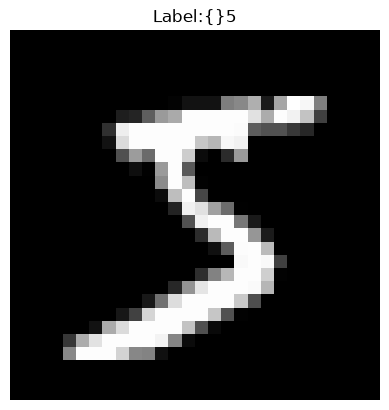

In [14]:
#we will display our first image
plt.imshow(x_train[0], cmap='gray')
plt.title("Label:{}" +str(y_train[0]))
plt.axis('off')
plt.show()

In [15]:
#we will normalize our data
x_train = x_train/255.0
x_test = x_test/255.0

In [16]:
#here we will reshape our data to fit the input shape of the CNN model
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

In [17]:
#now, lets start building the cnn model
model= tf.keras.models.Sequential()

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
938/938 [==============================] - 22s 24ms/step - loss: 0.0021 - accuracy: 0.9995 - val_loss: 0.0511 - val_accuracy: 0.9866
Epoch 2/5
938/938 [==============================] - 29s 31ms/step - loss: 0.0050 - accuracy: 0.9983 - val_loss: 0.0529 - val_accuracy: 0.9878
Epoch 3/5
938/938 [==============================] - 27s 29ms/step - loss: 0.0022 - accuracy: 0.9993 - val_loss: 0.0644 - val_accuracy: 0.9864
Epoch 4/5
938/938 [==============================] - 26s 27ms/step - loss: 0.0033 - accuracy: 0.9988 - val_loss: 0.0571 - val_accuracy: 0.9873
Epoch 5/5
938/938 [==============================] - 19s 20ms/step - loss: 0.0016 - accuracy: 0.9996 - val_loss: 0.0515 - val_accuracy: 0.9891


In [18]:
#first convolution layer
model.add(tf.keras.layers.MaxPool2D((2,2)))

In [19]:
model.add(tf.keras.layers.Conv2D(64,(3,3), activation='relu'))

In [20]:
model.add(tf.keras.layers.Conv2D(64,(3,3), activation='relu'))

In [21]:
model.add(tf.keras.layers.MaxPool2D((2,2)))

In [22]:
model.add(tf.keras.layers.Flatten())

In [23]:
#we will use our hidden layers with 64 neurons and relu activation function
model.add(tf.keras.layers.Dense(128, activation='relu'))

In [24]:
#output layer with 10 neurons and softmax activation function

model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [27]:
model.build(input_shape=(None, 32, 32, 3))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 3)         0         
 g2D)                                                            
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        1792      
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

In [28]:
#output model
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 3)         0         
 g2D)                                                            
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        1792      
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

In [31]:
loss='categorical_crossentropy'

In [33]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28, 1)
(60000,)


In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/5
938/938 [==============================] - 21s 22ms/step - loss: 0.0419 - accuracy: 0.9873 - val_loss: 0.0493 - val_accuracy: 0.9835
Epoch 2/5
938/938 [==============================] - 21s 23ms/step - loss: 0.0302 - accuracy: 0.9908 - val_loss: 0.0401 - val_accuracy: 0.9856
Epoch 3/5
938/938 [==============================] - 21s 23ms/step - loss: 0.0209 - accuracy: 0.9936 - val_loss: 0.0448 - val_accuracy: 0.9853
Epoch 4/5
938/938 [==============================] - 18s 19ms/step - loss: 0.0142 - accuracy: 0.9955 - val_loss: 0.0453 - val_accuracy: 0.9855
Epoch 5/5
938/938 [==============================] - 18s 19ms/step - loss: 0.0108 - accuracy: 0.9967 - val_loss: 0.0414 - val_accuracy: 0.9874


In [40]:
#now we will train our model
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test),batch_size=64)

Epoch 1/5
938/938 [==============================] - 23s 24ms/step - loss: 0.0076 - accuracy: 0.9976 - val_loss: 0.0514 - val_accuracy: 0.9864
Epoch 2/5
938/938 [==============================] - 19s 21ms/step - loss: 0.0059 - accuracy: 0.9980 - val_loss: 0.0510 - val_accuracy: 0.9860
Epoch 3/5
938/938 [==============================] - 17s 19ms/step - loss: 0.0058 - accuracy: 0.9981 - val_loss: 0.0624 - val_accuracy: 0.9837
Epoch 4/5
938/938 [==============================] - 17s 19ms/step - loss: 0.0035 - accuracy: 0.9990 - val_loss: 0.0635 - val_accuracy: 0.9849
Epoch 5/5
938/938 [==============================] - 18s 19ms/step - loss: 0.0039 - accuracy: 0.9988 - val_loss: 0.0455 - val_accuracy: 0.9885


In [41]:
loss,accuracy = model.evaluate(x_test,y_test)
print("Test loss:",loss)
print("Test Accuracy:",accuracy)

313/313 [==============================] - 1s 3ms/step - loss: 0.0455 - accuracy: 0.9885
Test loss: 0.04545760527253151
Test Accuracy: 0.9884999990463257


In [42]:
prediction=model.predict(x_test)
predicted_digit=np.argmax(prediction[0])

print("Predicted digit for the first image: ", predicted_digit)
print("Actual label for the first test image:",y_test[0])

313/313 [==============================] - 2s 4ms/step
Predicted digit for the first image:  7
Actual label for the first test image: 7


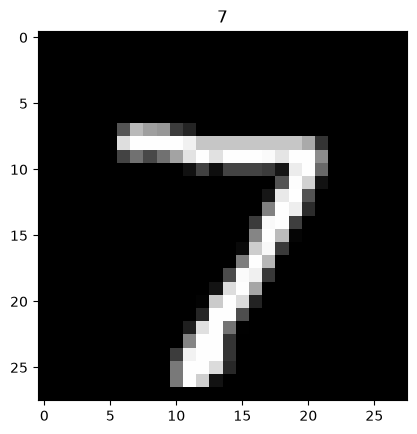

In [43]:
plt.imshow(x_test[0].reshape(28,28),cmap='gray')
plt.title(str(predicted_digit))
plt.axis('on')
plt.show()

1/1 [==============================] - 0s 48ms/step


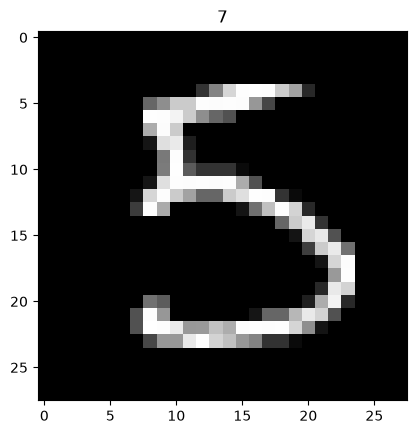

In [44]:
index =15
model.predict(x_test[index].reshape(1,28,28,1))
np.argmax(prediction)

plt.imshow(x_test[index].reshape(28,28),cmap='gray')
plt.title(str(predicted_digit))
plt.axis("on")
plt.show()

In [49]:
model.add(tf.keras.layers.Conv2D(64,(3,3), activation='relu'))

ValueError: Input 0 of layer "conv2d_7" is incompatible with the layer: expected min_ndim=4, found ndim=2. Full shape received: (None, 10)